In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, Dataset
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler, StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import mean_squared_error
from scipy.ndimage import gaussian_filter1d
import os
import gc

# ============================================================
# [1] 환경 설정 및 하이퍼파라미터
# ============================================================
RANDOM_STATE = 42
N_CLUSTERS = 6
VALID_RATIO = 0.2
WINDOW_SIZE = 30

# 컬럼 및 이름 정의 (사용자 로딩 방식에 맞춤)
ID_COLS = ['unit_nr', 'time_cycles']
OP_COLS = ['setting_1', 'setting_2', 'setting_3']
SENSOR_COLS = [f's_{i}' for i in range(1, 22)]
RAW_COLS = ['unit_nr', 'time_cycles', 'os_1', 'os_2', 'os_3'] + [f's_{i}' for i in range(1, 22)]
RENAME_MAP = {'os_1': 'setting_1', 'os_2': 'setting_2', 'os_3': 'setting_3'}

CONFIG = {
    'manual_remove_sensors': ['s_16', 's_19'],
    'rul_cap': 125,
    'normalize': 'standard', # standard, minmax
    'gaussian_sigma': 2,
    'emas': [],
    'diffs': [60],
    'epochs': 50
}

# ============================================================
# [2] 데이터 로딩 (사용자 제공 방식)
# ============================================================
DATA_DIR = 'CMAPSSData'
for c in ['../../CMAPSSData', './CMAPSSData', '../CMAPSSData']:
    if os.path.exists(os.path.join(c, 'train_FD002.txt')):
        DATA_DIR = c; break

kw = dict(sep=r'\s+', header=None, names=RAW_COLS, engine='python')
train_raw = pd.read_csv(f'{DATA_DIR}/train_FD002.txt', **kw)
test_raw  = pd.read_csv(f'{DATA_DIR}/test_FD002.txt',  **kw)
rul_df    = pd.read_csv(f'{DATA_DIR}/RUL_FD002.txt', sep=r'\s+', header=None, names=['RUL'], engine='python')

train_raw.rename(columns=RENAME_MAP, inplace=True)
test_raw.rename(columns=RENAME_MAP,  inplace=True)

print(f'✅ FD004 로딩 완료 | Train:{train_raw.shape} Test:{test_raw.shape} RUL:{rul_df.shape}')

# ============================================================
# [3] 전처리 함수 (기존 로직 유지)
# ============================================================
def filter_useful_sensors_v2(train_df, sensor_cols, manual_remove):
    remove = sorted(list(set(manual_remove))) if manual_remove else []
    useful = [s for s in sensor_cols if s not in remove]
    return useful, remove

def add_op_cluster(train_df, test_df, op_cols, k):
    op_scaler = MinMaxScaler()
    Xz_tr = op_scaler.fit_transform(train_df[op_cols])
    Xz_te = op_scaler.transform(test_df[op_cols])
    km = KMeans(n_clusters=k, random_state=RANDOM_STATE, n_init=20).fit(Xz_tr)
    tr, te = train_df.copy(), test_df.copy()
    tr['op_cluster'], te['op_cluster'] = km.labels_, km.predict(Xz_te)
    return tr, te

def add_piecewise_rul(df, cap):
    df = df.copy()
    mc = df.groupby('unit_nr')['time_cycles'].max()
    df = df.join(mc.rename('max_c'), on='unit_nr')
    df['RUL'] = (df['max_c'] - df['time_cycles']).clip(upper=cap)
    return df.drop('max_c', axis=1)

def normalize_by_cluster(sub, val, test, features, method, n_clusters):
    ScalerCls = {'minmax': MinMaxScaler, 'standard': StandardScaler}[method]
    sub, val, test, scalers = sub.copy(), val.copy(), test.copy(), {}
    for c in range(n_clusters):
        mask = sub['op_cluster'] == c
        if mask.sum() > 0:
            scaler = ScalerCls().fit(sub.loc[mask, features])
            sub.loc[mask, features] = scaler.transform(sub.loc[mask, features])
            scalers[c] = scaler
    for df in [val, test]:
        for c, sc in scalers.items():
            mask = df['op_cluster'] == c
            if mask.sum() > 0: df.loc[mask, features] = sc.transform(df.loc[mask, features])
    return sub, val, test

def apply_gaussian_by_cluster(df, features, sigma):
    if not sigma: return df
    df = df.copy().sort_values(['unit_nr', 'time_cycles'])
    for s in features:
        df[s] = df.groupby('unit_nr')[s].transform(lambda x: gaussian_filter1d(x.values.astype(np.float32), sigma=sigma))
    return df

def add_temporal_features(df, sensor_cols, cfg):
    df = df.copy().sort_values(['unit_nr', 'time_cycles'])
    for s in sensor_cols:
        if cfg.get('emas'):
            for span in cfg['emas']: df[f'{s}_ema{span}'] = df.groupby('unit_nr')[s].transform(lambda x: x.ewm(span=span, adjust=False).mean())
        if cfg.get('diffs'):
            for d in cfg['diffs']: df[f'{s}_diff{d}'] = df.groupby('unit_nr')[s].diff(d).fillna(0)
    return df.fillna(0)

# ============================================================
# [4] 시퀀스 생성 및 시각화 (에러 수정됨)
# ============================================================
def create_sequences_pt(df, feature_cols, target_col='RUL', window_size=30):
    x_list, y_list = [], []
    for uid in df['unit_nr'].unique():
        unit_df = df[df['unit_nr'] == uid].sort_values('time_cycles')
        if len(unit_df) < window_size: continue
        f_data = unit_df[feature_cols].values
        t_data = unit_df[target_col].values
        for i in range(len(unit_df) - window_size + 1):
            x_list.append(f_data[i:i+window_size])
            y_list.append(t_data[i+window_size-1])
    return np.array(x_list, dtype=np.float32), np.array(y_list, dtype=np.float32)

def create_test_sequences_pt(df, feature_cols, window_size=30):
    x_test_list = []
    for uid in np.sort(df['unit_nr'].unique()):
        unit_df = df[df['unit_nr'] == uid].sort_values('time_cycles')
        if len(unit_df) >= window_size:
            x_test_list.append(unit_df[feature_cols].values[-window_size:])
        else:
            pad = np.zeros((window_size - len(unit_df), len(feature_cols)))
            x_test_list.append(np.vstack([pad, unit_df[feature_cols].values]))
    return np.array(x_test_list, dtype=np.float32)

def calculate_nasa_score(y_true, y_pred):
    d = y_pred - y_true
    score = np.where(d < 0, np.exp(-d / 13) - 1, np.exp(d / 10) - 1)
    return np.sum(score)

def evaluate_dl_pipeline(model, model_name, history, X_val, y_val, X_test, y_test, feature_names):
    model.eval()
    device = next(model.parameters()).device
    with torch.no_grad():
        val_pred = model(torch.tensor(X_val).to(device)).cpu().numpy()
        test_pred = model(torch.tensor(X_test).to(device)).cpu().numpy()

    # 타겟 데이터 차원 맞춤
    val_pred = val_pred.reshape(-1)
    test_pred = test_pred.reshape(-1)

    rmse_test = np.sqrt(mean_squared_error(y_test, test_pred))
    nasa_test = calculate_nasa_score(y_test, test_pred)
    print(f"\n🏆 {model_name} Result: RMSE {rmse_test:.4f} | NASA {nasa_test:.2f}")

    fig, axes = plt.subplots(2, 3, figsize=(22, 10))
    
    # 1. Loss Curve
    axes[0, 0].plot(history['train_loss'], label='Train')
    axes[0, 0].plot(history['val_loss'], label='Val')
    axes[0, 0].set_title('1. Loss Curve'); axes[0, 0].legend()
    
    # 2. Residual Plot
    axes[0, 1].scatter(val_pred, y_val - val_pred, alpha=0.2, color='orange')
    axes[0, 1].axhline(0, color='red', linestyle='--')
    axes[0, 1].set_title('2. Residual Plot (Validation)')
    
    # 3. Feature Weights (가장 중요한 수정 지점)
    ax3 = axes[0, 2]
    try:
        # 첫 번째 파라미터 추출
        first_param = next(model.parameters()).detach().cpu().numpy()
        
        # 모델 타입별 가중치 처리
        if first_param.ndim == 3:  # CNN: (out_channels, in_channels, kernel)
            # 입력 피처(in_channels) 차원인 axis=1을 남기고 평균
            w = np.mean(np.abs(first_param), axis=(0, 2))
        elif first_param.ndim == 2: # Linear or RNN: (hidden, input)
            # 입력 피처 차원인 axis=1을 남기고 평균
            w = np.mean(np.abs(first_param), axis=0)
        else:
            w = np.abs(first_param)

        # 가중치와 피처 이름 개수 강제 매칭
        w = w[:len(feature_names)] 
        
        n_show = min(15, len(w))
        idx = np.argsort(w)[-n_show:]
        
        ax3.barh(range(n_show), w[idx], color='teal')
        ax3.set_yticks(range(n_show))
        ax3.set_yticklabels(np.array(feature_names)[idx])
        ax3.set_title(f'3. Top {n_show} Feature Weights')
    except Exception as e:
        ax3.set_title('3. Weights (N/A)')
        print(f"Weight visualization skipped: {e}")

    # 4. Distribution
    sns.kdeplot(y_val, label='Actual', ax=axes[1, 0], fill=True)
    sns.kdeplot(val_pred, label='Pred', ax=axes[1, 0], fill=True)
    axes[1, 0].set_title('4. Val Target Distribution'); axes[1, 0].legend()
    
    # 5. Weight Histogram
    if 'w' in locals():
        axes[1, 1].hist(w, bins=20, color='purple', alpha=0.7)
        axes[1, 1].set_title('5. Input Weight Distribution')
    
    # 6. Test Prediction Line
    axes[1, 2].plot(y_test, 'k', label='Actual', alpha=0.7)
    axes[1, 2].plot(test_pred, 'r--', label='Pred', alpha=0.7)
    axes[1, 2].set_title('6. Test Actual vs Pred'); axes[1, 2].legend()
    
    plt.tight_layout(); plt.show()

# [필수] 파이토치 전용 데이터셋 클래스
class Dataset_pt(Dataset):
    def __init__(self, x, y):
        self.x = torch.tensor(x, dtype=torch.float32)
        self.y = torch.tensor(y, dtype=torch.float32)
        
    def __len__(self):
        return len(self.x)
        
    def __getitem__(self, i):
        return self.x[i], self.y[i]

# [참고] 시퀀스 데이터 생성 함수 (이미 실행했다면 생략 가능)
def create_sequences_pt(df, feature_cols, target_col='RUL', window_size=30):
    x_list, y_list = [], []
    for uid in df['unit_nr'].unique():
        unit_df = df[df['unit_nr'] == uid].sort_values('time_cycles')
        if len(unit_df) < window_size: continue
        f_data = unit_df[feature_cols].values
        t_data = unit_df[target_col].values
        for i in range(len(unit_df) - window_size + 1):
            x_list.append(f_data[i:i+window_size])
            y_list.append(t_data[i+window_size-1])
    return np.array(x_list, dtype=np.float32), np.array(y_list, dtype=np.float32)

# ============================================================
# [5] 모델 정의 및 실행 함수
# ============================================================
# 1. CNN (BatchNorm & Deep FC 적용)
class OptimizedCNN(nn.Module):
    def __init__(self, in_dim):
        super().__init__()
        self.conv = nn.Sequential(
            nn.Conv1d(in_dim, 128, kernel_size=3, padding=1),
            nn.BatchNorm1d(128), nn.ReLU(), nn.Dropout(0.2),
            nn.Conv1d(128, 64, kernel_size=3, padding=1),
            nn.BatchNorm1d(64), nn.ReLU(), nn.Flatten()
        )
        self.fc = nn.Sequential(
            nn.Linear(64 * WINDOW_SIZE, 128), nn.ReLU(), nn.Dropout(0.2),
            nn.Linear(128, 1)
        )
    def forward(self, x):
        return self.fc(self.conv(x.transpose(1, 2))).squeeze()

# 2. LSTM (Deep & Dropout 최적화)
class OptimizedLSTM(nn.Module):
    def __init__(self, in_dim):
        super().__init__()
        self.lstm = nn.LSTM(in_dim, 128, num_layers=2, batch_first=True, dropout=0.3)
        self.fc = nn.Sequential(
            nn.Linear(128, 64), nn.ReLU(), nn.Linear(64, 1)
        )
    def forward(self, x):
        out, _ = self.lstm(x)
        return self.fc(out[:, -1, :]).squeeze()

# 3. BiLSTM (양방향 정보 활용 극대화)
class OptimizedBiLSTM(nn.Module):
    def __init__(self, in_dim):
        super().__init__()
        self.lstm = nn.LSTM(in_dim, 64, num_layers=2, batch_first=True, bidirectional=True, dropout=0.3)
        self.fc = nn.Sequential(
            nn.Linear(128, 64), nn.ReLU(), nn.Linear(64, 1)
        )
    def forward(self, x):
        out, _ = self.lstm(x)
        return self.fc(out[:, -1, :]).squeeze()

# 4. Transformer (LayerNorm & Multi-Head Attention 안정화)
class OptimizedTransformer(nn.Module):
    def __init__(self, in_dim):
        super().__init__()
        self.embed = nn.Linear(in_dim, 128)
        self.pos_dropout = nn.Dropout(0.1)
        encoder_layer = nn.TransformerEncoderLayer(d_model=128, nhead=8, dim_feedforward=256, batch_first=True, dropout=0.2)
        self.transformer = nn.TransformerEncoder(encoder_layer, num_layers=3)
        self.fc = nn.Sequential(
            nn.Linear(128, 64), nn.ReLU(), nn.Linear(64, 1)
        )
    def forward(self, x):
        x = self.pos_dropout(self.embed(x))
        x = self.transformer(x)
        return self.fc(x[:, -1, :]).squeeze()

# 5. CNN-Transformer Hybrid (특징 추출 + 시계열 맥락)
class OptimizedHybrid(nn.Module):
    def __init__(self, in_dim):
        super().__init__()
        self.cnn = nn.Sequential(
            nn.Conv1d(in_dim, 128, kernel_size=3, padding=1),
            nn.BatchNorm1d(128), nn.ReLU()
        )
        encoder_layer = nn.TransformerEncoderLayer(d_model=128, nhead=8, batch_first=True, dropout=0.2)
        self.transformer = nn.TransformerEncoder(encoder_layer, num_layers=2)
        self.fc = nn.Linear(128, 1)
    def forward(self, x):
        x = self.cnn(x.transpose(1, 2)).transpose(1, 2)
        x = self.transformer(x)
        return self.fc(x[:, -1, :]).squeeze()

# 전처리 파이프라인 가동
useful, _ = filter_useful_sensors_v2(train_raw, SENSOR_COLS, CONFIG['manual_remove_sensors'])
tr_cl, te_cl = add_op_cluster(train_raw, test_raw, OP_COLS, N_CLUSTERS)
tr_cl = add_piecewise_rul(tr_cl, CONFIG['rul_cap'])

# 분할
sub_units, val_units = train_test_split(tr_cl['unit_nr'].unique(), test_size=VALID_RATIO, random_state=RANDOM_STATE)
sub_df, val_df = tr_cl[tr_cl['unit_nr'].isin(sub_units)].copy(), tr_cl[tr_cl['unit_nr'].isin(val_units)].copy()

# 정규화 및 추가 피처
sub_df, val_df, te_df = normalize_by_cluster(sub_df, val_df, te_cl, useful, CONFIG['normalize'], N_CLUSTERS)
sub_df = add_temporal_features(apply_gaussian_by_cluster(sub_df, useful, CONFIG['gaussian_sigma']), useful, CONFIG)
val_df = add_temporal_features(apply_gaussian_by_cluster(val_df, useful, CONFIG['gaussian_sigma']), useful, CONFIG)
te_df  = add_temporal_features(apply_gaussian_by_cluster(te_df, useful, CONFIG['gaussian_sigma']), useful, CONFIG)

# One-Hot Cluster
ohe_cols = [f'cluster_{i}' for i in range(N_CLUSTERS)]
def apply_ohe(df):
    ohe = pd.get_dummies(df['op_cluster'], prefix='cluster').astype(np.float32)
    for col in ohe_cols: 
        if col not in ohe.columns: ohe[col] = 0.0
    return pd.concat([df.reset_index(drop=True), ohe[ohe_cols].reset_index(drop=True)], axis=1)

train_f, valid_f, test_f = apply_ohe(sub_df), apply_ohe(val_df), apply_ohe(te_df)

ML_FEATURES = [c for c in train_f.columns if c not in (ID_COLS + OP_COLS + ['op_cluster', 'RUL'])]

# 텐서 준비
X_tr, y_tr = create_sequences_pt(train_f, ML_FEATURES, window_size=WINDOW_SIZE)
X_va, y_va = create_sequences_pt(valid_f, ML_FEATURES, window_size=WINDOW_SIZE)
X_te = create_test_sequences_pt(test_f, ML_FEATURES, window_size=WINDOW_SIZE)
y_te = rul_df['RUL'].values.astype(np.float32)

import torch.optim.lr_scheduler as lr_scheduler

def run_model_optimized(model_obj, model_name, epochs=50):
    device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
    model = model_obj.to(device)
    
    # 튜닝된 옵티마이저 (L2 Regularization 추가)
    optimizer = optim.AdamW(model.parameters(), lr=0.001, weight_decay=1e-4)
    
    # 성능 보완: 학습률 스케줄러 (Val Loss가 정체되면 lr 0.5배 감소)
    scheduler = lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=5)    
    criterion = nn.MSELoss()
    train_loader = DataLoader(Dataset_pt(X_tr, y_tr), batch_size=128, shuffle=True)
    
    history = {'train_loss': [], 'val_loss': []}
    
    print(f"\n🔥 {model_name} 최적화 학습 시작")
    for epoch in range(epochs):
        model.train()
        t_loss = 0
        for bx, by in train_loader:
            bx, by = bx.to(device), by.to(device)
            optimizer.zero_grad()
            loss = criterion(model(bx), by)
            loss.backward()
            
            # 성능 보완: Gradient Clipping (LSTM/BiLSTM 안정화 핵심)
            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
            
            optimizer.step()
            t_loss += loss.item()
        
        model.eval()
        with torch.no_grad():
            v_loss = criterion(model(torch.tensor(X_va).to(device)), torch.tensor(y_va).to(device)).item()
        
        history['train_loss'].append(t_loss/len(train_loader))
        history['val_loss'].append(v_loss)
        scheduler.step(v_loss) # 스케줄러 업데이트
        
        if (epoch+1) % 10 == 0:
            print(f" Epoch {epoch+1:2d} | Val Loss: {v_loss:.4f} | LR: {optimizer.param_groups[0]['lr']:.6f}")

    # 시각화 및 평가
    evaluate_dl_pipeline(model, model_name, history, X_va, y_va, X_te, y_te, ML_FEATURES)
    del model; gc.collect(); torch.cuda.empty_cache()


✅ FD004 로딩 완료 | Train:(53759, 26) Test:(33991, 26) RUL:(259, 1)


C:\Users\yesyo\AppData\Local\Temp\ipykernel_91120\2276745610.py:91: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '[-0.76383951 -1.47678703 -0.76383951 ...  2.08795057  2.08795057
  2.08795057]' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.
  sub.loc[mask, features] = scaler.transform(sub.loc[mask, features])
C:\Users\yesyo\AppData\Local\Temp\ipykernel_91120\2276745610.py:96: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '[-2.18973455 -0.76383951 -1.47678703 ...  2.08795057  2.08795057
  1.37500305]' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.
  if mask.sum() > 0: df.loc[mask, features] = sc.transform(df.loc[mask, features])
C:\Users\yesyo\AppData\Local\Temp\ipykernel_91120\2276745610.py:96: FutureWarning: Setting an item of incompatible dtyp


🔥 CNN_v2 최적화 학습 시작
 Epoch 10 | Val Loss: 393.7431 | LR: 0.001000
 Epoch 20 | Val Loss: 169.5361 | LR: 0.000500
 Epoch 30 | Val Loss: 459.6578 | LR: 0.000250
 Epoch 40 | Val Loss: 166.9405 | LR: 0.000063
 Epoch 50 | Val Loss: 176.9250 | LR: 0.000063

🏆 CNN_v2 Result: RMSE 25.8130 | NASA 5644.20


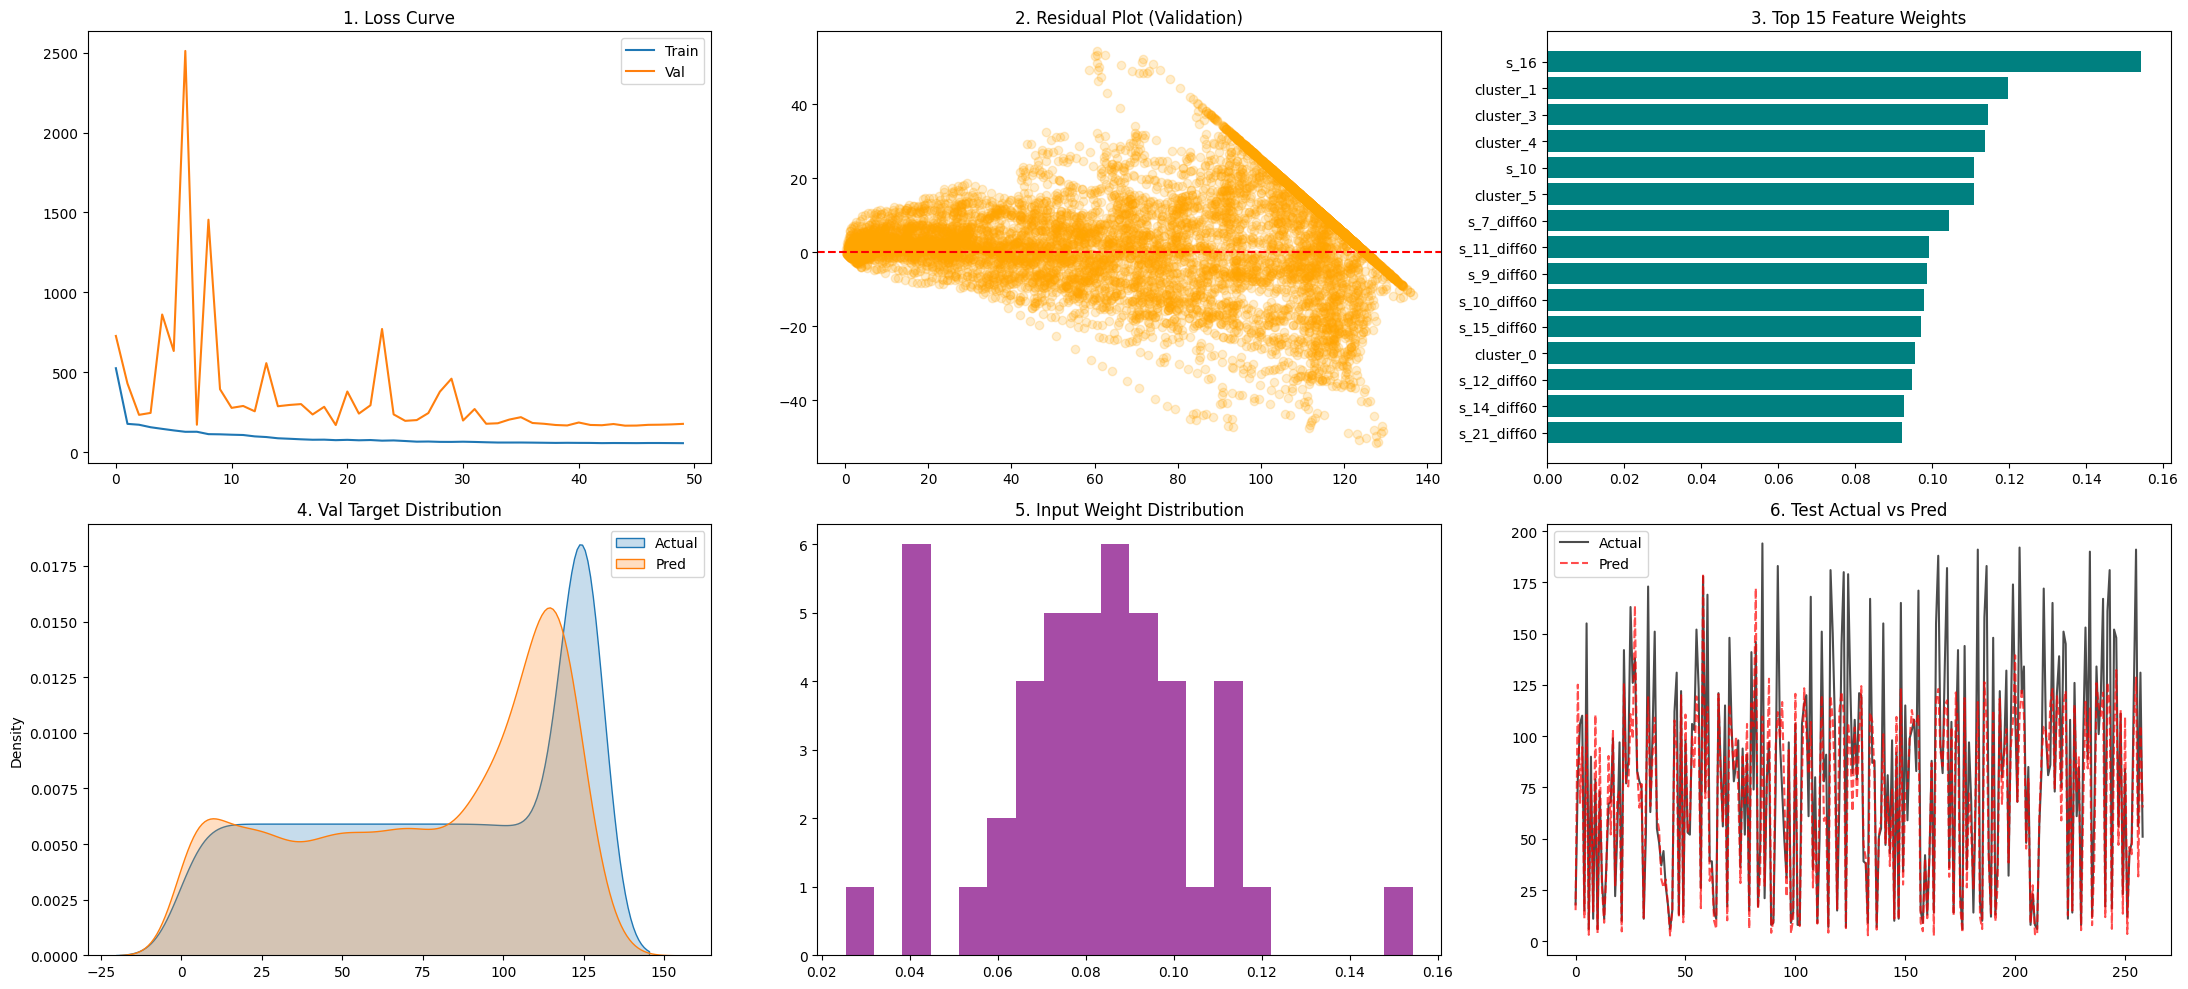


🔥 LSTM_v2 최적화 학습 시작
 Epoch 10 | Val Loss: 132.6861 | LR: 0.000500
 Epoch 20 | Val Loss: 151.6540 | LR: 0.000250
 Epoch 30 | Val Loss: 164.5909 | LR: 0.000063
 Epoch 40 | Val Loss: 169.9730 | LR: 0.000016
 Epoch 50 | Val Loss: 168.5731 | LR: 0.000008

🏆 LSTM_v2 Result: RMSE 23.7043 | NASA 3641.68


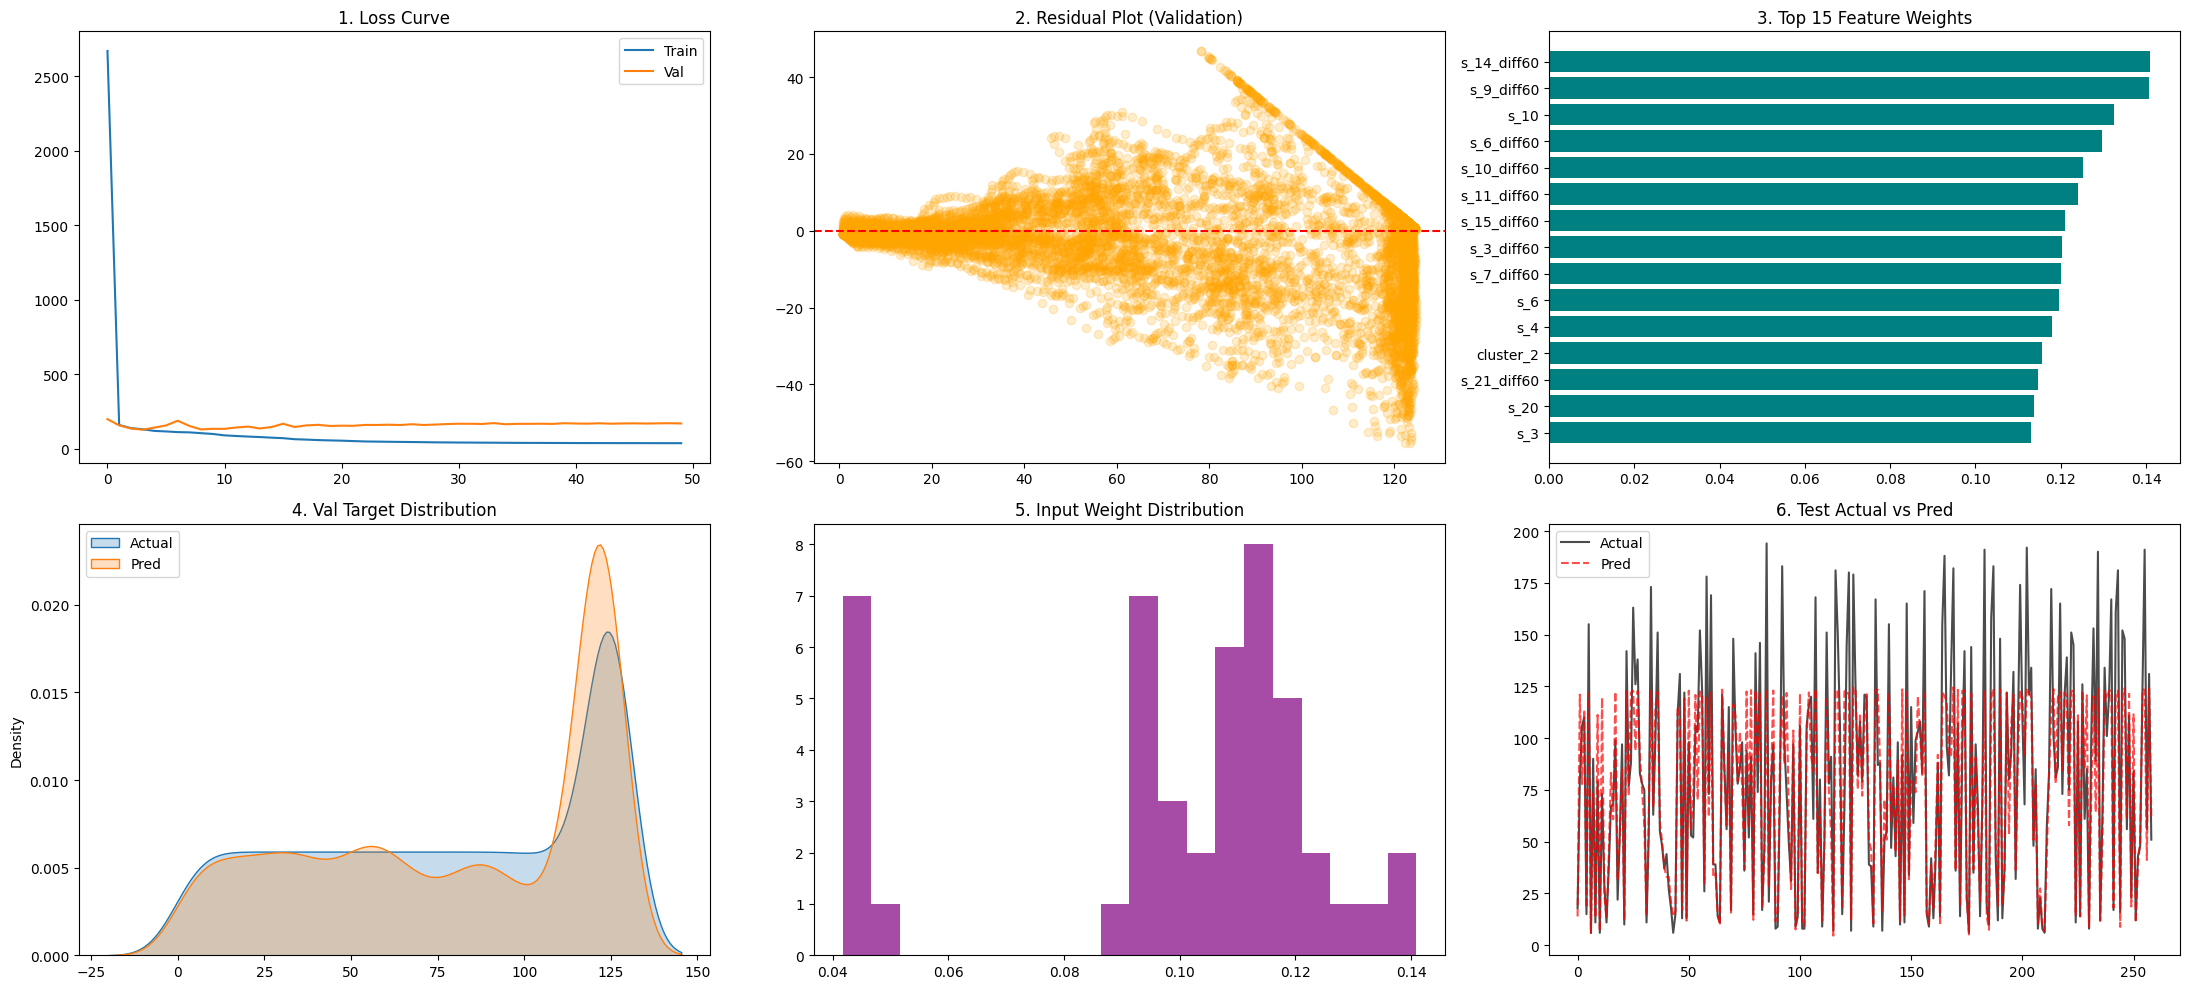


🔥 BiLSTM_v2 최적화 학습 시작
 Epoch 10 | Val Loss: 148.4985 | LR: 0.001000
 Epoch 20 | Val Loss: 135.6835 | LR: 0.000250
 Epoch 30 | Val Loss: 150.7106 | LR: 0.000125
 Epoch 40 | Val Loss: 158.5728 | LR: 0.000031
 Epoch 50 | Val Loss: 162.9596 | LR: 0.000008

🏆 BiLSTM_v2 Result: RMSE 23.9561 | NASA 3747.08


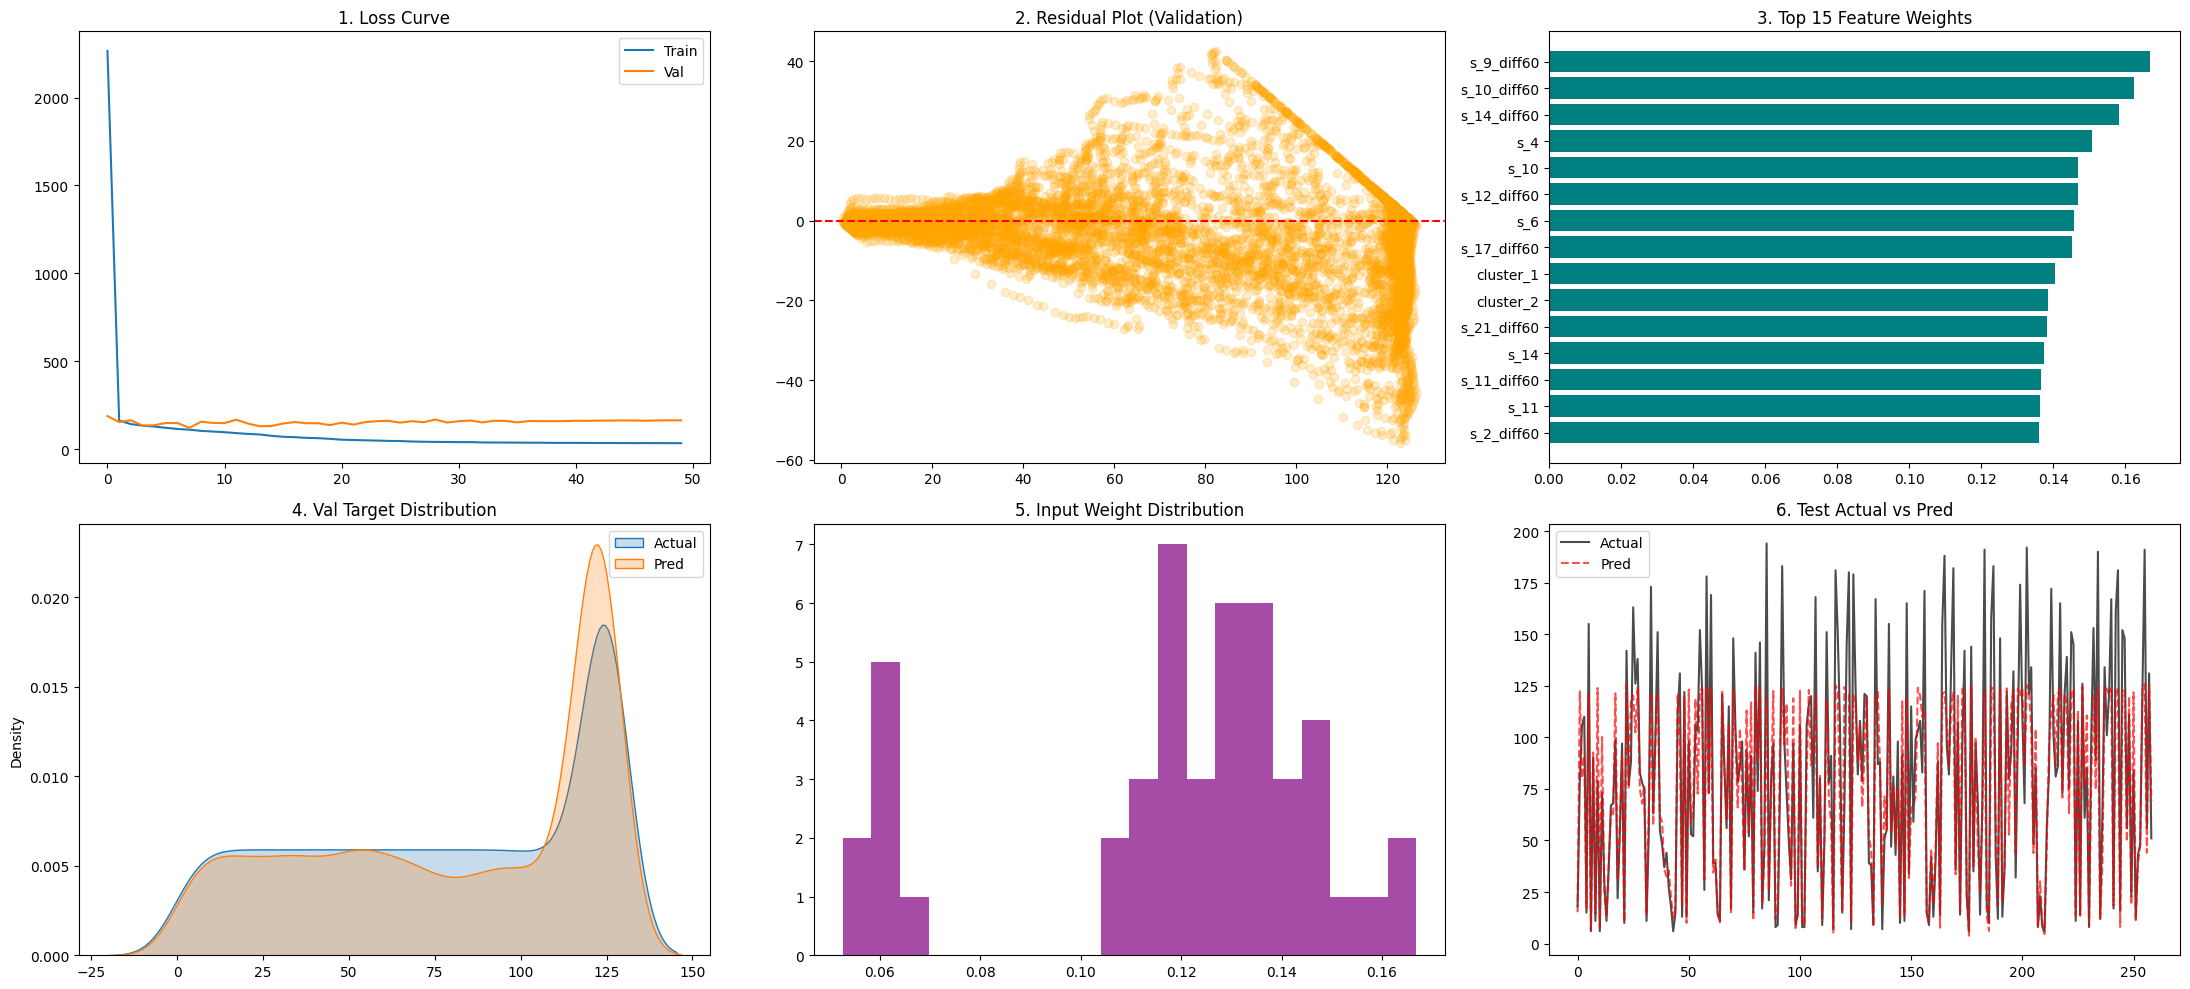


🔥 Transformer_v2 최적화 학습 시작
 Epoch 10 | Val Loss: 231.2591 | LR: 0.001000
 Epoch 20 | Val Loss: 176.9281 | LR: 0.000500
 Epoch 30 | Val Loss: 189.1116 | LR: 0.000125
 Epoch 40 | Val Loss: 199.6520 | LR: 0.000031
 Epoch 50 | Val Loss: 199.7174 | LR: 0.000016

🏆 Transformer_v2 Result: RMSE 23.7999 | NASA 4607.88


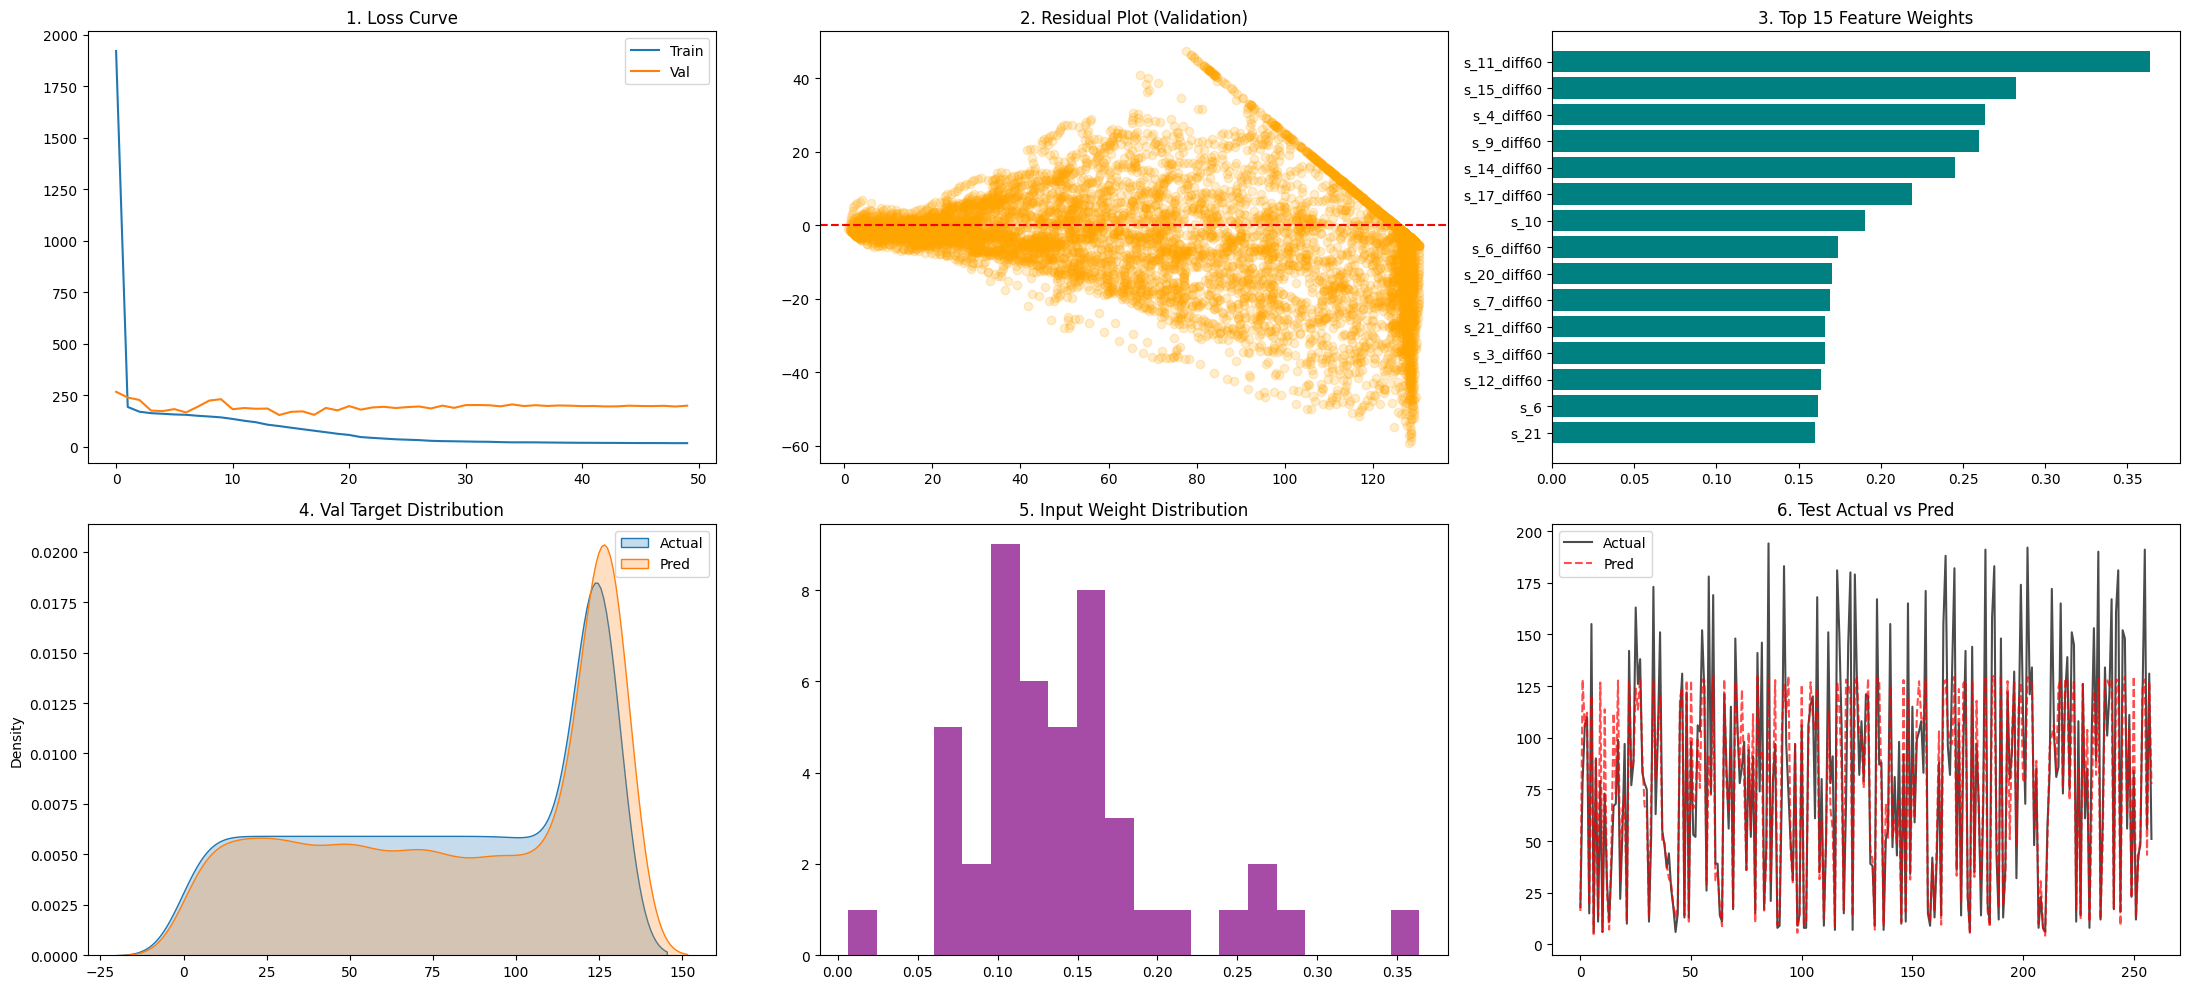


🔥 CNN+Transformer 최적화 학습 시작
 Epoch 10 | Val Loss: 213.0323 | LR: 0.001000
 Epoch 20 | Val Loss: 222.6404 | LR: 0.000500
 Epoch 30 | Val Loss: 206.7894 | LR: 0.000125
 Epoch 40 | Val Loss: 206.4006 | LR: 0.000031
 Epoch 50 | Val Loss: 209.6097 | LR: 0.000016

🏆 CNN+Transformer Result: RMSE 23.8652 | NASA 4615.80


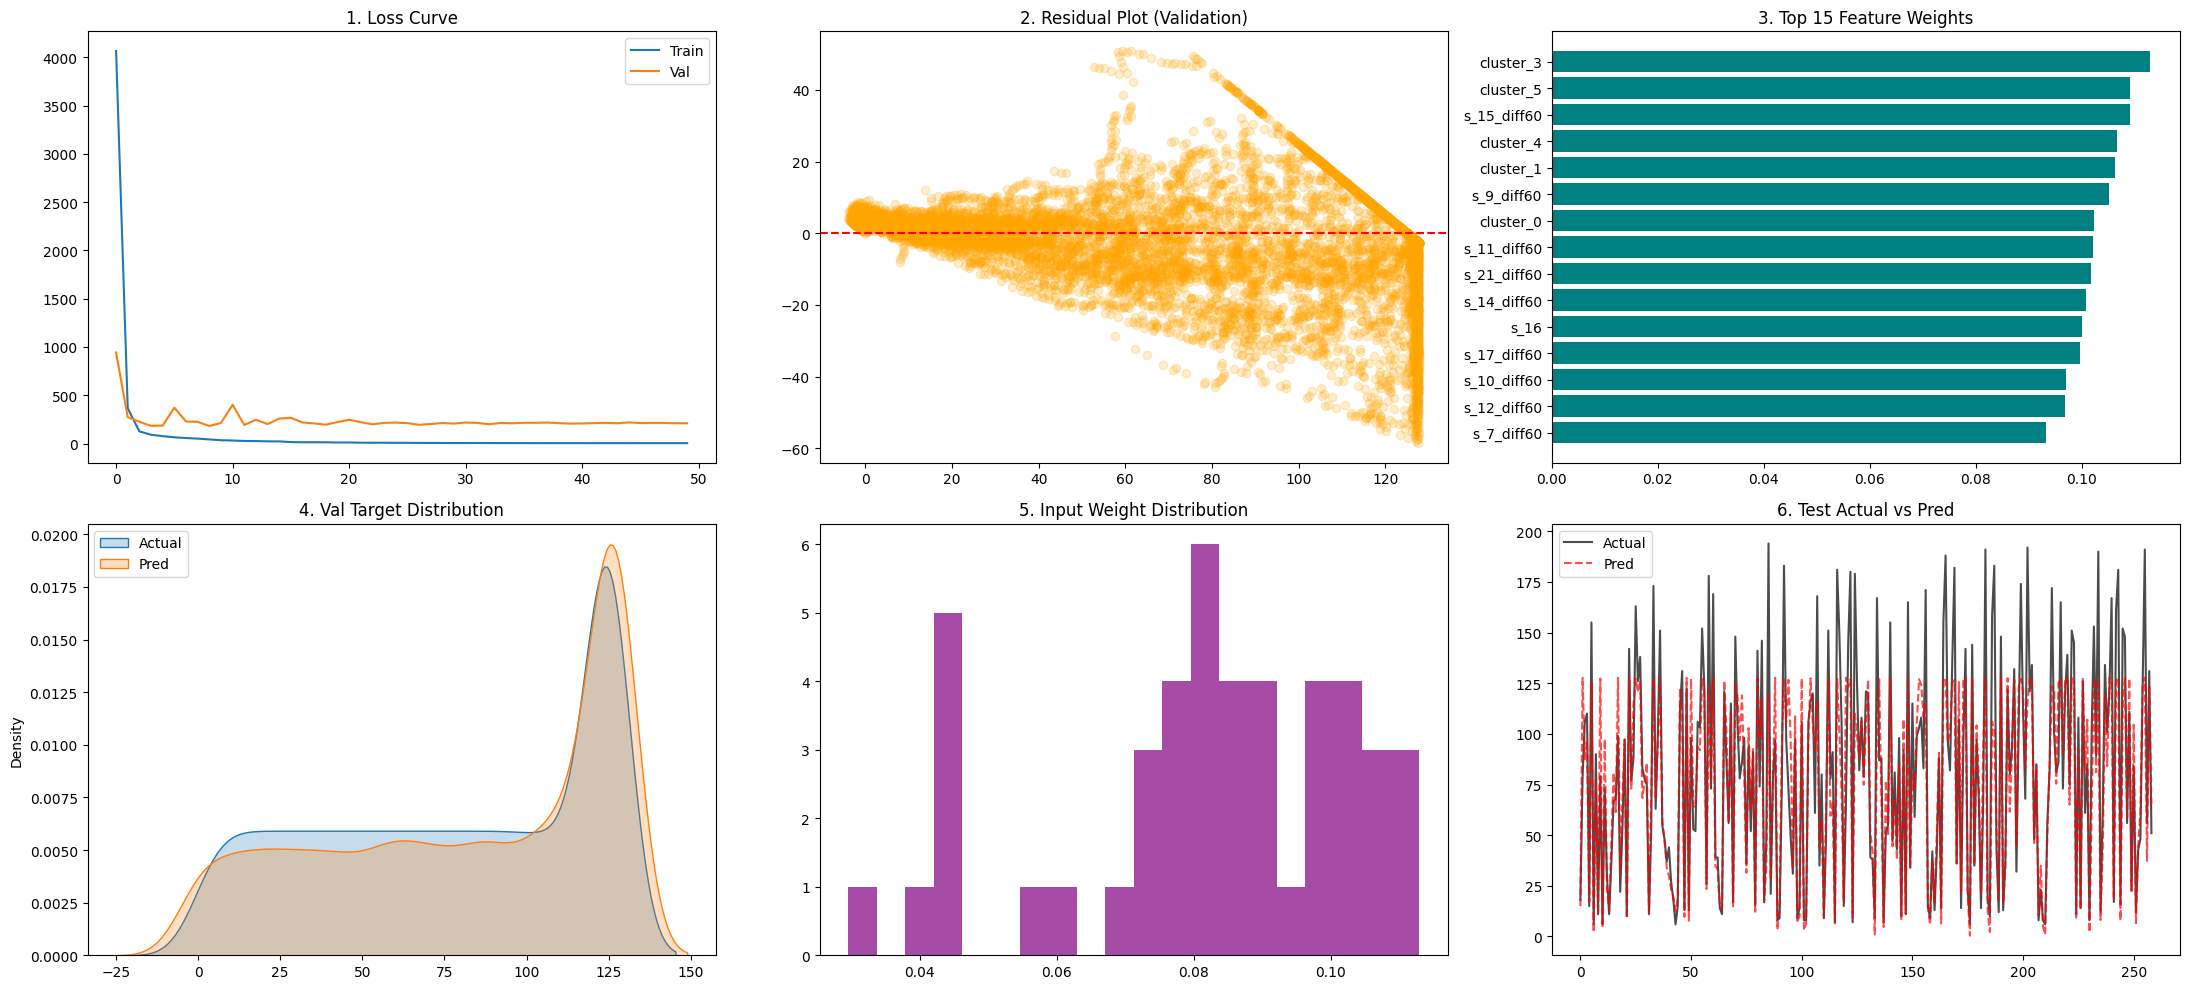

In [2]:
# 실행 예시
run_model_optimized(OptimizedCNN(len(ML_FEATURES)), "CNN_v2")
run_model_optimized(OptimizedLSTM(len(ML_FEATURES)), "LSTM_v2")
run_model_optimized(OptimizedBiLSTM(len(ML_FEATURES)), "BiLSTM_v2")
run_model_optimized(OptimizedTransformer(len(ML_FEATURES)), "Transformer_v2")
run_model_optimized(OptimizedHybrid(len(ML_FEATURES)), "CNN+Transformer")